In [1]:
%pip install davos
import davos

davos.config.suppress_stdout = True

Note: you may need to restart the kernel to use updated packages.


In [8]:
smuggle numpy as np       # pip: numpy==1.24.3
smuggle pandas as pd      # pip: pandas==2.0.1
smuggle hypertools as hyp # pip: hypertools==0.8.0
smuggle seaborn as sns    # pip: seaborn==0.12.2

smuggle sklearn as sk     # pip: scikit-learn==1.2.2
from sklearn.cluster import KMeans

smuggle scipy as sp       # pip: scipy==1.10.1
from scipy.spatial.distance import pdist, cdist, squareform

from mat73 smuggle loadmat # pip: mat73==0.60

smuggle requests          # pip: requests==2.28.2
smuggle nibabel as nib    # pip: nibabel==5.1.0
smuggle timecorr as tc    # pip: git+https://github.com/ContextLab/timecorr@9d567e2
smuggle nilearn as nl     # pip: nilearn==0.10.1
from nilearn.maskers import NiftiMasker
from nilearn.plotting import plot_anat, plot_glass_brain
from bids smuggle BIDSLayout, BIDSValidator  # pip: pybids==0.16.1

from matplotlib smuggle pyplot as plt  # pip: matplotlib==3.7.1
from matplotlib import animation as ani
from tqdm smuggle tqdm    # pip: tqdm==4.64.1

import warnings
import os
import shutil
import zipfile
import pickle
from glob import glob as lsdir

from helpers import nii2cmu, cmu2nii, basedir, figdir, datadir, scratch_dir, raw_data_url, get_factors, get_weights

%matplotlib inline

In [3]:
raw_datadir = os.path.join(datadir, 'DFFR')
if not os.path.exists(raw_datadir):
    raw_zip = os.path.join(datadir, 'DFFR.zip')
    if not os.path.exists(raw_zip):
        print('Downloading raw data...')
        with open(raw_zip, 'wb') as f:
            data = requests.get(raw_data_url).content
            f.write(data)

    print('Extracting raw data...')
    with zipfile.ZipFile(raw_zip, 'r') as zip_ref:
        zip_ref.extractall(datadir)
    shutil.rmtree(os.path.join(datadir, '__MACOSX'))
    os.remove(raw_zip)

In [53]:
files = lsdir(os.path.join(datadir, 'regressors', '*regs_results.mat'))

In [54]:
files

['/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/112013_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/111313_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/092513_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/081413_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/103013_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/091113_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/082813_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/101613_DFFR_0_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regressors/112013_DFFR_1_regs_results.mat',
 '/Users/jmanning/directed-forgetting-network-dynamics/data/regr

In [49]:
regressors = {os.path.split(r)[1][:-4]: loadmat(r) for r in lsdir(os.path.join(datadir, 'regressors', '*_0.mat')) + lsdir(os.path.join(datadir, 'regressors', '*_1.mat'))}

In [52]:
regressors['082813_DFFR_0'].keys()

dict_keys(['L1_objects', 'L1_recalls', 'L1_rest', 'L1_scenes', 'L1_scrambled_scenes', 'L2_objects', 'L2_recalls', 'L2_rest', 'L2_scenes', 'L2_scrambled_scenes', 'correct_recalls', 'cue_objects', 'cue_rest', 'cue_scenes', 'cue_scrambled_scenes', 'cuetype', 'last_image_objects', 'last_image_rest', 'last_image_scenes', 'last_image_scrambled_scenes', 'pfr', 'rec_objects', 'rec_rest', 'rec_scenes', 'rec_scrambled_scenes', 'reclist', 'recmats', 'spc', 'start_objects', 'start_rest', 'start_scenes', 'start_scrambled_scenes', 'tempfact'])

In [56]:
x = sp.io.loadmat(files[0])

<Axes: >

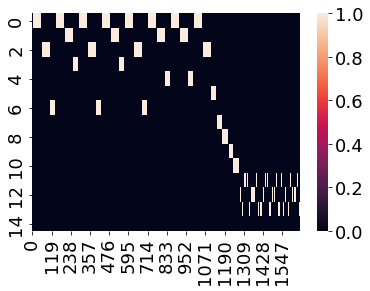

In [61]:
sns.heatmap(x['all_regressors'])

In [71]:
pd.read_csv(os.path.join(datadir, 'regressors', 'key.csv'))

,block,list_id,cue,behavior,stimulus
0,1,1,NaN,present,word
1,1,2,remember,present,word
2,1,2,forget,present,word
3,1,1,remember,recall,NaN
4,1,2,remember,recall,NaN
5,1,1,forget,recall,NaN
6,1,2,forget,recall,NaN
7,2,1,NaN,present,word
8,2,1,NaN,recall,NaN
9,2,2,NaN,present,word


In [6]:
layout = BIDSLayout(os.path.join(datadir, 'DFFR'), derivatives=False)

In [27]:
img = nib.load(layout.get(subject='01', extension='.nii.gz', return_type='file')[0])

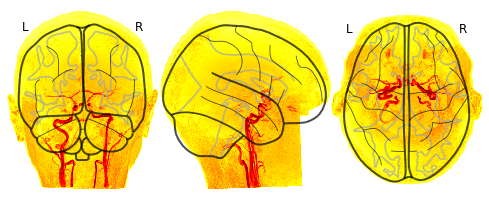

In [31]:
plot_glass_brain(img)

In [5]:
# datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
# nii_files = lsdir(os.path.join(datadir, '*.nii'))
# regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))
# #cluster_masks = os.path.join('clusters', 'k50_2mm_gm_split_cleaned.nii.gz')
# #cluster_masks = os.path.join('clusters', 'Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')
# cluster_masks = os.path.join('clusters', 'Schaefer2018_100Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')
# kernel_weights = tc.gaussian_weights
# kernel_params = {'var': 10}

# figdir = os.path.join('figs', 'gaussian', 'var10', 'Schaefer', '100_parcels')
# if not os.path.exists(figdir):
#     os.makedirs(figdir)

Create $K$ RBF nodes, scattered throughout the standard MNI brain

In [40]:
K = 1000
width = 25

template_fname = os.path.join(datadir, 'MNI152_T1_2mm_brain.nii.gz')
template = nii2cmu(template_fname)

kmeans = KMeans(n_clusters=K, random_state=0, n_init='auto').fit(template['R'])
centers = kmeans.cluster_centers_
widths = np.ones(K) * width

In [71]:
def fname2id(fname):
    info = os.path.split(fname)[1].split('_')
    return f'{info[0]}_{info[2]}'

In [92]:
def reduce(fname, centers, widths):
    img = nii2cmu(fname)
    F = get_factors(img['R'], centers, widths)
    return get_weights(img['Y'], F)

In [73]:
fnames = lsdir(os.path.join(datadir, 'DFFR', '*', 'func', '*.nii.gz'))

In [74]:
fname = fnames[0]

In [75]:
img = nii2cmu(fname)

In [93]:
W = reduce(fname, centers, widths)

In [78]:
from scipy.spatial.distance import cdist, pdist, squareform

In [94]:
c1 = 1 - squareform(pdist(img['Y'], metric='correlation'))
c2 = 1 - squareform(pdist(W, metric='correlation'))

In [95]:
np.mean(c1)

0.9983650096046223

In [96]:
np.mean(c2)

0.9999639640631662

<Axes: >

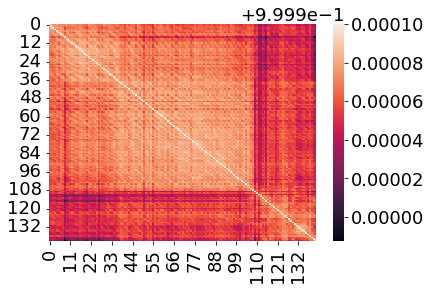

In [97]:
sns.heatmap(c2)

In [100]:
img2 = nii2cmu(fnames[1])
W2 = reduce(fnames[1], centers, widths)

In [102]:
img3 = nii2cmu(fnames[100])
W3 = reduce(fnames[100], centers, widths)

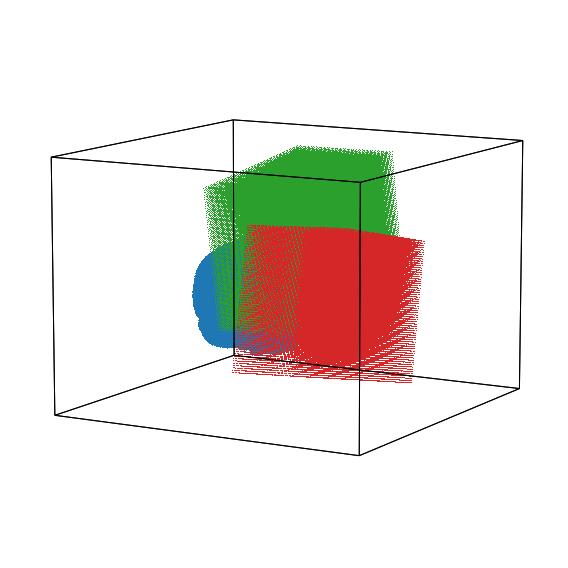

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection='3d'))
x = hyp.plot([template['R'], img['R'], img2['R'], img3['R']], ',', ax=ax)

Compute "weights" of each image on each cluster's RBF.  Obtain a number-of-images by $K$ matrix for each .nii.gz file, for each subject.  Save them as pickled files.

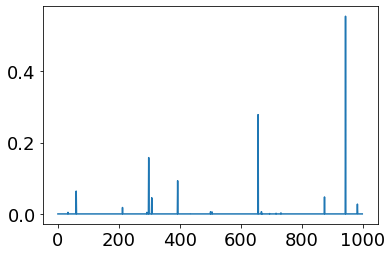

In [21]:
plt.plot(F[:, 0])

In [23]:
# for each ... # TODO: implement this...

(1000, 3)

Notes:
  - sanity check: plot MNI coords + coords for each participant's images on the same 3d scatterplot
  - for each image (from each run/participant) compare the timepoints-by-timepoints correlation matrices for the original data vs. "summarized" data
    - compute correlations between the upper triangles of both matrices (1 val per run per participant)
    - plot distribution of correlation coefficients

In [5]:
def apply_mask(data, mask):
    data = data.get_data()
    mask = mask.get_data()
    
    separated = (np.ndim(mask) > 3)
    
    T = data.shape[3]
    
    if separated:
        K = mask.shape[3]
    else:
        labels = np.unique(mask)
        labels = labels[labels > 0]
        K = len(labels)
    Y = np.zeros([T, K])
    
    for k in np.arange(K):
        if separated:
            roi_mask = mask[:, :, :, k]
            roi_inds = np.where(roi_mask)
        else:
            roi_inds = np.where(mask == labels[k])
        Y[:, k] = np.mean(data[roi_inds[0], roi_inds[1], roi_inds[2], :], axis=0)
    return Y

In [6]:
def get_cluster_centers(mask, node_color='k', node_size=10, plot_it=True, **kwargs):
    mask_bo = se.Brain(mask, filter=None)
    data = mask_bo.data
    locs = mask_bo.locs
    
    separated = (data.shape[0] > 1)
    if separated:
        K = data.shape[0]
    else:
        labels = np.unique(data)
        labels = labels[labels > 0]
        K = len(labels)
    
    centers = np.zeros([K, locs.shape[1]])
    widths = np.zeros([K, 1])
    
    for k in np.arange(K):
        if separated:
            inds = np.where(data.iloc[k, :] == 1)[0]
        else:
            inds = np.where(data.iloc[0, :] == labels[k])[0]
        centers[k, :] = locs.iloc[inds, :].mean(axis=0)
        widths[k] = np.sqrt(((locs.iloc[inds, :] - centers[k, :]) ** 2).sum(axis=1)).mean(axis=0)
    
    if plot_it:
        nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_color=node_color, node_size=(widths ** 2) / 10, **kwargs)
    
    return centers, widths

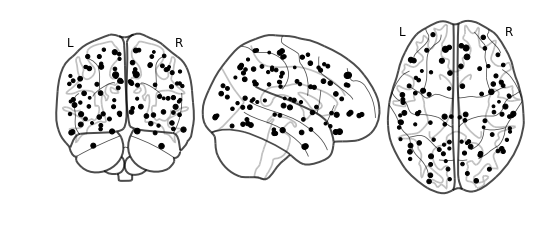

In [7]:
mask = nib.load(cluster_masks)
centers, widths = get_cluster_centers(mask)

In [8]:
def package_data(masked_data, nii_files, regressor_files):
    nii_subjs = list(map(lambda f: f.split('/')[-1][:-len('.nii')], nii_files))
    reg_subjs = list(map(lambda f: f.split('/')[-1][:-len('_regs_results.mat')], regressor_files))
    
    data = []
    for i, s in enumerate(nii_subjs):
        try:
            j = np.ravel(np.where(np.array(list(map(lambda x: x == s, reg_subjs)))))[0]
            print(f'matching {s} with {regressor_files[j]}')
            regmat = load(regressor_files[j])
            data.append({'data': masked_data[i], 'regmat': regmat['all_regressors'], 'mvpa': regmat['results']})
        except:
            print(f'missing data for {s}')
    return data

In [10]:
data_fname = os.path.join('data', f'preprocessed_{cluster_masks.split(os.path.sep)[1][:-len(".nii.gz")]}.npz')
if os.path.exists(data_fname):
    print('loading preprocessed data from disk...')
    data = np.load(data_fname)['data']
else:
    print('preprocessing data...')
    masked_data = list(map(lambda f: apply_mask(nib.load(f), mask), nii_files))
    data = package_data(masked_data, nii_files, regressor_files)
    np.savez(data_fname, data=data)

loading preprocessed data from disk...


In [11]:
regressors_key = ['Present list A', 
                  'Present list B (R)', 
                  'Present list B (F)',
                  'Recall list A (R)',
                  'Recall list B (R)', 
                  'Recall list A (F)',
                  'Recall list B (F)',
                  'Present localizer list 1',
                  'Recall localizer list 1',
                  'Present localizer list 2',
                  'Recall localizer list 2',
                  'Present scene localizer image',
                  'Present objects localizer image',
                  'Present scrambled scene localizer image']
present_a = [0]
present_b = [1, 2]
forget = [2, 5, 6]
remember = [1, 3, 4]

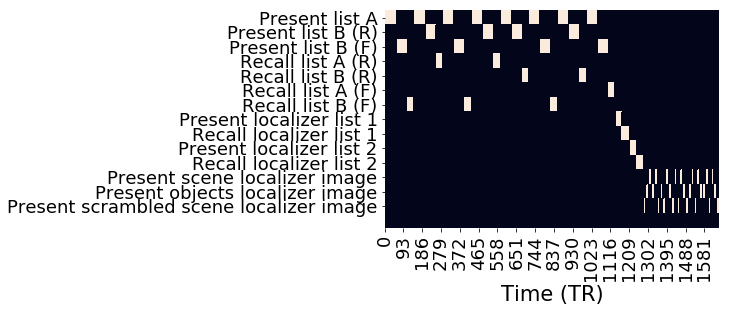

In [12]:
#experiment labels from participant 0
h = sns.heatmap(data[0]['regmat'], cbar=False)
h.set_yticks(np.arange(len(regressors_key)) + 0.5)
h.set_yticklabels(regressors_key)
plt.yticks(rotation=0);
plt.xlabel('Time (TR)');

In [13]:
def get_keys(inds):
    keys = []
    for i in inds:
        keys.append(regressors_key[i])
    return keys

In [14]:
print(get_keys(present_a))
print(get_keys(present_b))
print(get_keys(remember))
print(get_keys(forget))

['Present list A']
['Present list B (R)', 'Present list B (F)']
['Present list B (R)', 'Recall list A (R)', 'Recall list B (R)']
['Present list B (F)', 'Recall list A (F)', 'Recall list B (F)']


In [15]:
def get_bounds(x): #x is a line from a regressors matrix
    diffs = np.diff(np.array(x, dtype=np.float)) #strange things happen when x is an array of ints
    return np.where(diffs == 1)[0], np.where(diffs == -1)[0] #event starts, ends

In [16]:
def get_events(data, event_times, before=25, after=25):
    '''
    return the data, centered on each event_time. the resulting matrix is of shape
    (before + after + 1) by data.shape[1] by len(event_times).  if an event starts
    or ends too close to the beginning or end of the given data, the slice of that
    event's representation in the result will contain nans to reflect the missing
    data.
    '''
    
    x = np.multiply(np.nan, np.zeros([before + after + 1, data.shape[1], len(event_times)]))
    for i, t in enumerate(event_times):
        start_time = t - before - 1
        end_time = t + after
        
        if start_time >= 0:
            start_ind = 0
        else:
            start_ind = np.abs(start_time)
            start_time = 0
        
        if end_time <= data.shape[0]:
            end_ind = before + after + 1
        else:
            end_ind = end_time - data.shape[0]
            end_time = data.shape[0]
        
        x[start_ind:end_ind, :, i] = data[start_time:end_time, :]
    return x

In [17]:
def get_network_dynamics(x, rows, offset=0, before=50, after=50, **kwargs):
    def copier(a):
        if type(a) == list:
            return list(map(copier, a))
        return np.copy(a)
    
    if not (type(rows) == list):
        rows = [rows]
        delist = True
    else:
        delist = False
    
    nets = []
    for r in rows:
        next_data = list(map(lambda y: get_events(y['data'], get_bounds(y['regmat'][r, :])[0] + offset, before=before, after=after), x))
        next_means = list(map(lambda y: np.nanmean(y, axis=2), next_data))
        nets.append(tc.timecorr(copier(next_means), **kwargs))        
    if delist:
        return nets[0]
    else:
        return nets

In [18]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [19]:
def ribbon(x, y, lb, ub=None, color='k', alpha=0.5):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

In [20]:
def event_ribbon(x, ts=None, limit_t=None, color='k', alpha=0.5):
    if ts is None:
        ts = np.arange(-(x.shape[0] - 1)/2, (x.shape[0] - 1)/2 + 1) #assume centered data
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    x = x[inds, :]
    ts = ts[inds]
                
    m = np.nanmean(x, axis=1)
    ci = 1.96*np.divide(np.nanstd(x, axis=1), np.sqrt(x.shape[1])) # 95% confidence intervals
    
    return ribbon(ts, m, ci, ci, color=color, alpha=alpha)

In [21]:
buffer = 50
r_f_nets = get_network_dynamics(data, [1, 2], weights_function=kernel_weights, weights_params=kernel_params, before=buffer, after=buffer, offset=0, include_timepoints='pre', exclude_timepoints=10)


In [22]:
means = list(map(tc.corrmean_combine, r_f_nets))
diffs = list(map(lambda x, y: x - y, r_f_nets[0], r_f_nets[1]))
tvals, pvals = tc.tstat_combine(diffs, return_pvals=True)
filtered_tvals = np.multiply(tvals, (pvals < 0.0001/np.sum(np.isnan(pvals)))) #Bonferroni corrected p < 0.0001

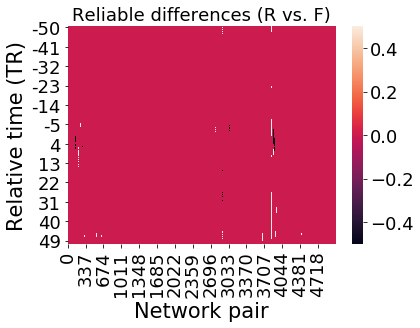

In [23]:
sns.heatmap(pd.DataFrame(np.multiply(tvals, (pvals < 0.05/np.sum(np.isnan(pvals)))), index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Reliable differences (R vs. F)');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

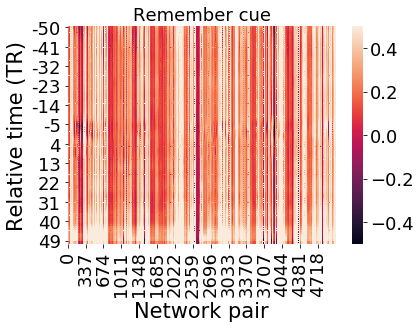

In [24]:
sns.heatmap(pd.DataFrame(means[0], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Remember cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

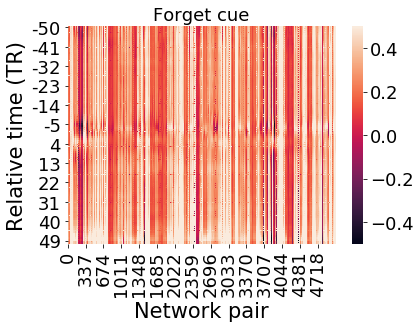

In [25]:
sns.heatmap(pd.DataFrame(means[1], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Forget cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

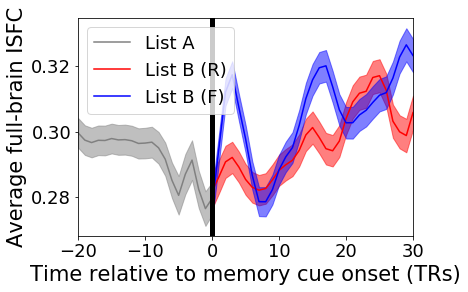

In [26]:
ts = np.arange(-buffer, buffer+1)
min_time = -20
max_time = 30

colors = [[0.5, 0.5, 0.5], 'r', 'b']
event_ribbon(np.mean(np.concatenate([means[0][:, :, np.newaxis], means[1][:, :, np.newaxis]], axis=2), axis=2), ts=ts, color=colors[0], limit_t=[min_time, 0]);
event_ribbon(means[0], ts=ts, color=colors[1], limit_t=[0, max_time]);
event_ribbon(means[1], ts=ts, color=colors[2], limit_t=[0, max_time]);
plt.legend(['List A', 'List B (R)', 'List B (F)'])


plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('Average full-brain ISFC')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 'ribbon_plot.pdf'))

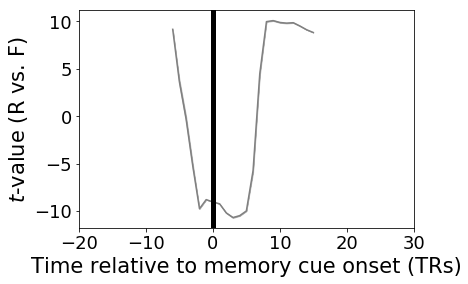

In [33]:
nanned_filtered_tvals = filtered_tvals
nanned_filtered_tvals[nanned_filtered_tvals == 0] = np.nan
event_ribbon(filtered_tvals, ts=ts, color=[0.5, 0.5, 0.5], limit_t=[min_time, max_time])
plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('$t$-value (R vs. F)')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 't_vals_timeseries.pdf'))

In [34]:
eng = mlab.start_matlab()

In [35]:
def mlab_array(x):    
    return matlab.double(x.tolist())

In [36]:
def BrainNet_animation(centers, widths, connections, outfile, ts=None, limit_t=None, force_refresh=False):
    if ts is None:
        ts = np.arange(connections.shape[2])
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    ts = ts[inds]
    connections = connections[:, :, inds]
    
    for i, t in enumerate(ts):
        next_fname = outfile + '_' + '{:03d}'.format(i) + '.jpg'
        if (not os.path.exists(next_fname)) or force_refresh:
            eng.TFA_BrainNet_wrapper(mlab_array(centers), mlab_array(widths), mlab_array(np.squeeze(connections[:, :, i])), next_fname, os.path.join('data', 'brainnet_config_DF.mat'), nargout=0)
                                            

In [37]:
BrainNet_animation(centers, widths, tc.vec2mat(filtered_tvals), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'diffs'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[0]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'remember'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[1]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'forget'), force_refresh=True)

In [44]:
eng.exit()

In [38]:
!ffmpeg -i {figdir}/diffs_%03d.jpg -c:v libx264 -r 25 {figdir}/diffs.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/diffs_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/u

In [42]:
!ffmpeg -i {figdir}/remember_%03d.jpg -c:v libx264 -r 25 {figdir}/remember.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/remember_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470b

In [43]:
!ffmpeg -i {figdir}/forget_%03d.jpg -c:v libx264 -r 25 {figdir}/forget.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/forget_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/